In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10

##Datasets and DataLoaders

In [2]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
# image scale (0,1) and normalize (-1,1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


In [3]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [11]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

##Building CNN

In [12]:
from torch.nn.modules.pooling import MaxPool2d
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()
    self.conv_layers = nn.Sequential(
        nn.Conv2d(3,32,kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2), #kernel size =2 & stride=2

        nn.Conv2d(32,64,kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2), #kernel size =2 & stride=2

        nn.Conv2d(64,128,kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.fc_layers = nn.Sequential(
        nn.Linear(4*4*128,256),
        nn.ReLU(),

        nn.Linear(256,10)
    )

  def forward(self,x):
    x = self.conv_layers(x)
    x = x.view(x.size(0),-1) # flattening the output
    x = self.fc_layers(x)
    return x

In [13]:
model = CNN()

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Training The CNN

In [15]:
epochs = 10
for epoch in range(epochs):
  epochs_training_loss = 0.0

  for images,labels in trainloader:
    optimizer.zero_grad()
    output = model.forward(images) #FP
    loss = criterion(output,labels) #loss fix
    loss.backward() #BP
    optimizer.step() # update params

    epochs_training_loss += loss.item()

  print(f"epoch={epoch+1}/{epochs} & loss={epochs_training_loss/len(trainloader)}")

epoch=1/10 & loss=1.3463577324777003
epoch=2/10 & loss=0.9260400351508499
epoch=3/10 & loss=0.7462413575490723
epoch=4/10 & loss=0.612693210582599
epoch=5/10 & loss=0.5084048612305271
epoch=6/10 & loss=0.4101677620807267
epoch=7/10 & loss=0.32341339947927333
epoch=8/10 & loss=0.2467985505862233
epoch=9/10 & loss=0.18971904612067717
epoch=10/10 & loss=0.14186931173067036


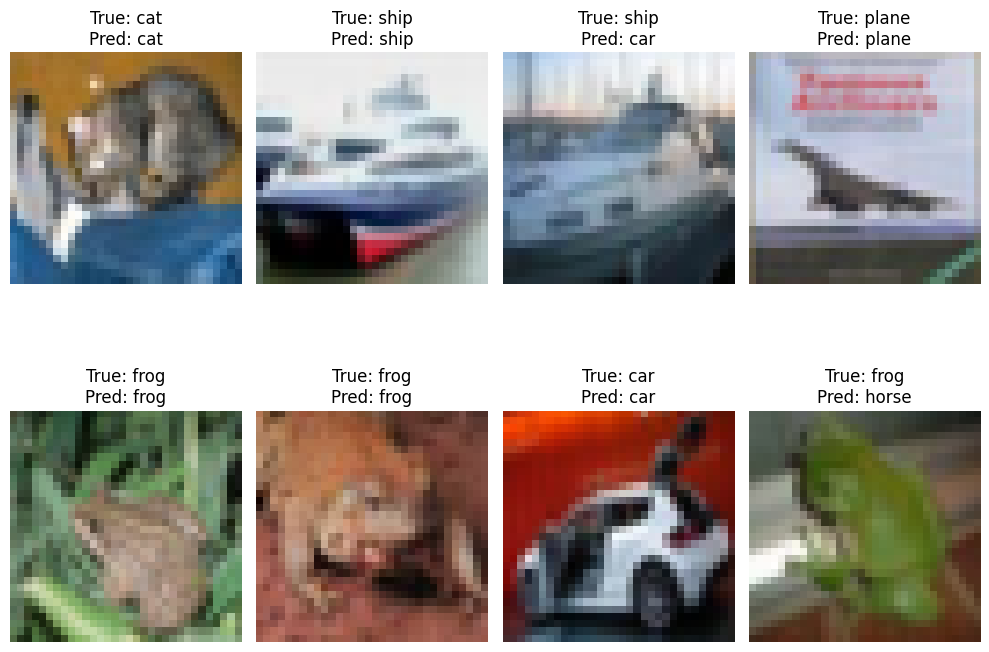

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Get a batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Make predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Show images with true and predicted labels
fig = plt.figure(figsize=(10, 8))
for i in range(min(len(images), 8)): # Display up to 8 images
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    imshow(torchvision.utils.make_grid(images[i]/2 + 0.5), # Unnormalize for display
           f'True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}')
plt.tight_layout()
plt.show()

In [9]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # Disable gradient computation during evaluation
  for images, labels in testloader:
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total}%')

Accuracy of the network on the 10000 test images: 96.39%
